In this assignment we are tasked to build a visual perception system that detects and tracks multiple objects across image sequences that are extracted from video. There are two object classes targeted; **Orange Ball** (`ball`) and **Blue Cup** (`cup`).

The objectives are to do:
1. **Object Detection**: Predict bounding boxes and class labels per frame.
2. **Multi-Object Tracking**: Assign and maintain consistent `track_id` values across frames to handle occlusion, disappearance, and re-identification.

### **Setting up**

Import all libraries needed

In [1]:
import shutil
import pathlib
import random
import zipfile

import gdown
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image, ImageDraw, ImageFont

import torch
from ultralytics import YOLO
from scipy.optimize import linear_sum_assignment
import imageio

Defining global paths and constants used throughout the notebook (see `README.md` for the project structure)

In [2]:
BASE_DIR = pathlib.Path("..").resolve()

# Dataset directories
DATA_DIR = BASE_DIR / "data"

DATASET_A = DATA_DIR / "Vid_A_ball"
DATASET_B = DATA_DIR / "Vid_B_cup"
DATASET_C = DATA_DIR / "Vid_C_mixed"

# Ground truth CSV files
GT_A = DATA_DIR / "metadata" / "ground_truth_A.csv"
GT_B = DATA_DIR / "metadata" / "ground_truth_B.csv"

# YOLO dataset
YOLO_DIR = DATA_DIR / "yolo_dataset"

# Model checkpoints
MODEL_DIR = BASE_DIR / "models"

# Inference outputs (CSV predictions and videos)
OUTPUT_DIR = DATA_DIR / "output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Image dimensions, class mappings, random seed
IMG_W = 320
IMG_H = 240

CLASS_NAMES = [
    "ball",
    "cup"
]

CLASS_IDS = {
    "ball": 0,
    "cup": 1
}

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

# Device selection
if torch.backends.mps.is_available():
    DEVICE = "mps"
elif torch.cuda.is_available():
    DEVICE = "cuda"
else:
    DEVICE = "cpu"
print(f"Using device: {DEVICE}")

Using device: mps


### **Data Download**

Since the image data are too large for git, I have hosted the image sequences on Google Drive. We can run this section once to download and extract them automatically. Full dataset [here](https://drive.google.com/drive/folders/1zpJItUwYdkeaXafp0tCUu39KfUmeWFY2?hl=id)

In [3]:
GDRIVE_IDS = {
    "Vid_A_ball": "1KqIlZbNKXRyPEURiZoK1Vc6BBQW50Ws6",   
    "Vid_B_cup": "1yvVTBQZ9nsJDN0ioHZIeMvGQlVQCHpa1",   
    "Vid_C_mixed": "1OkBp-XnOsV2CkdXA2_H5iw7rvUZUfkOr", 
}

def download_dataset(name: str, file_id: str, dest_dir: pathlib.Path):
    if dest_dir.exists() and any(dest_dir.glob("img*.jpg")):
        print(f"{name}: already present, skipping download.")
        return

    zip_path = DATA_DIR / f"{name}.zip"
    print(f"Downloading {name}...")
    gdown.download(id=file_id, output=str(zip_path), quiet=False)

    print(f"Extracting {name}")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(DATA_DIR)
    zip_path.unlink()
    print(f"{name}: ready at {dest_dir}")


for ds_name, (ds_dir, ds_id) in {
    "Vid_A_ball": (DATASET_A, GDRIVE_IDS["Vid_A_ball"]),
    "Vid_B_cup": (DATASET_B, GDRIVE_IDS["Vid_B_cup"]),
    "Vid_C_mixed": (DATASET_C, GDRIVE_IDS["Vid_C_mixed"]),
}.items():
    download_dataset(ds_name, ds_id, ds_dir)

Downloading...
From: https://drive.google.com/uc?id=1KqIlZbNKXRyPEURiZoK1Vc6BBQW50Ws6
To: /Users/rafaeldewandaru/KULIAH/SEMESTER 8/DATMIN/Tugas 4/Rafael/video_mining/data/Vid_A_ball.zip
100%|██████████| 6.63M/6.63M [00:05<00:00, 1.12MB/s]


Extracting Vid_A_ball
Vid_A_ball: ready at /Users/rafaeldewandaru/KULIAH/SEMESTER 8/DATMIN/Tugas 4/Rafael/video_mining/data/Vid_A_ball


Downloading...
From: https://drive.google.com/uc?id=1yvVTBQZ9nsJDN0ioHZIeMvGQlVQCHpa1
To: /Users/rafaeldewandaru/KULIAH/SEMESTER 8/DATMIN/Tugas 4/Rafael/video_mining/data/Vid_B_cup.zip
100%|██████████| 9.18M/9.18M [00:08<00:00, 1.13MB/s]


Extracting Vid_B_cup
Vid_B_cup: ready at /Users/rafaeldewandaru/KULIAH/SEMESTER 8/DATMIN/Tugas 4/Rafael/video_mining/data/Vid_B_cup


Downloading...
From: https://drive.google.com/uc?id=1OkBp-XnOsV2CkdXA2_H5iw7rvUZUfkOr
To: /Users/rafaeldewandaru/KULIAH/SEMESTER 8/DATMIN/Tugas 4/Rafael/video_mining/data/Vid_C_mixed.zip
100%|██████████| 6.52M/6.52M [00:14<00:00, 454kB/s]

Extracting Vid_C_mixed
Vid_C_mixed: ready at /Users/rafaeldewandaru/KULIAH/SEMESTER 8/DATMIN/Tugas 4/Rafael/video_mining/data/Vid_C_mixed


### **Exploratory Data Analysis**

Inspect each dataset to see the frame count, ground-truth row count, unique object IDs, and sample frames with bounding boxes overlaid.

In [4]:
def load_gt(csv_path: pathlib.Path) -> pd.DataFrame:
    if not csv_path.exists():
        return pd.DataFrame()
    return pd.read_csv(csv_path)

def get_image_paths(dataset_dir: pathlib.Path):
    return sorted(dataset_dir.glob("*.jpg"))

Dataset A (ball): 421 frames - GT rows: 421 - Unique IDs: 1 - Frames with GT: 421
Dataset B (cup): 440 frames - GT rows: 440 - Unique IDs: 1 - Frames with GT: 440
Dataset C (mixed): 404 frames - No ground truth


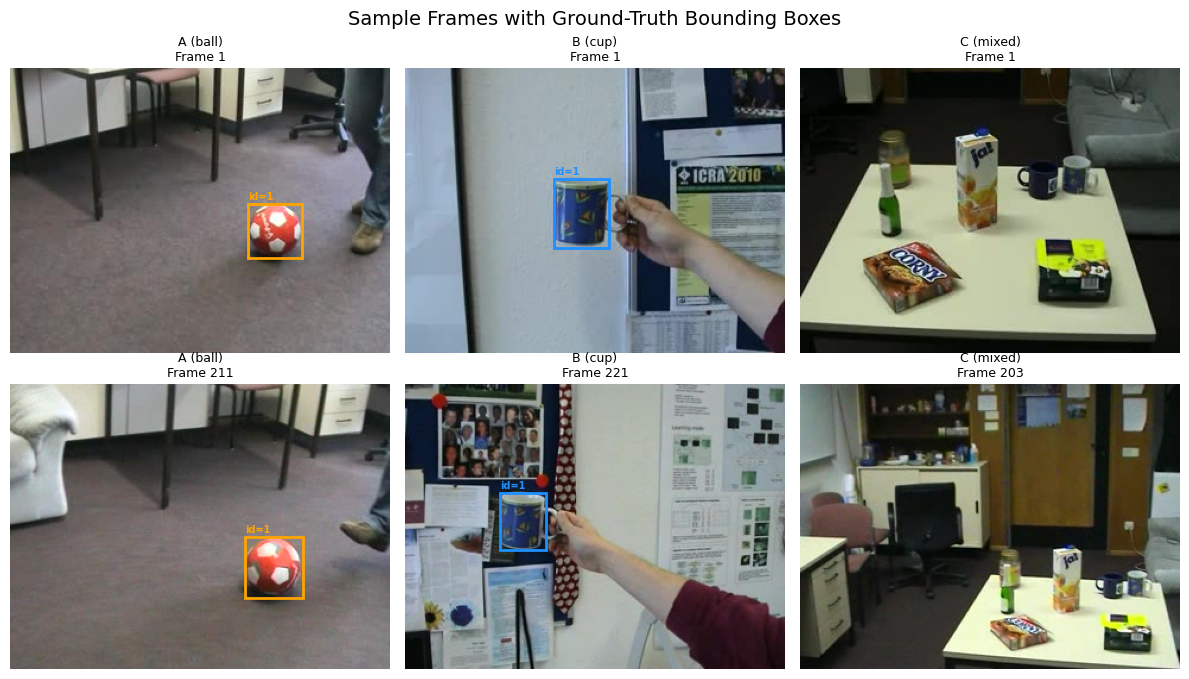

In [5]:
datasets_meta = [
    ("A (ball)", DATASET_A, GT_A, "orange"),
    ("B (cup)", DATASET_B, GT_B, "dodgerblue"),
    ("C (mixed)", DATASET_C, None, None),
]

for name, dset, gt_path, _ in datasets_meta:
    imgs = get_image_paths(dset)
    gt_df = load_gt(gt_path) if gt_path else pd.DataFrame()
    print(f"Dataset {name}: {len(imgs)} frames", end="")
    if not gt_df.empty:
        print(
            f" - GT rows: {len(gt_df)}"
            f" - Unique IDs: {gt_df['id'].nunique()}"
            f" - Frames with GT: {gt_df['frame'].nunique()}"
        )
    else:
        print(" - No ground truth")

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
fig.suptitle("Sample Frames with Ground-Truth Bounding Boxes", fontsize=14)

gt_dfs = [load_gt(GT_A), load_gt(GT_B), pd.DataFrame()]

for col, (title, dset, _, color) in enumerate(datasets_meta):
    imgs = get_image_paths(dset)
    frame_indices = [0, len(imgs) // 2]
    for row, fidx in enumerate(frame_indices):
        ax = axes[row][col]
        img_path = imgs[fidx]
        frame_num = int(img_path.stem[3:])
        img = Image.open(img_path)
        ax.imshow(img)
        ax.set_title(f"{title}\nFrame {frame_num}", fontsize=9)
        ax.axis("off")

        gt = gt_dfs[col]
        if not gt.empty:
            frame_gt = gt[gt["frame"] == frame_num]
            for _, row_data in frame_gt.iterrows():
                x1, y1 = row_data["topLeftX"], row_data["topLeftY"]
                x2, y2 = row_data["bottomRightX"], row_data["bottomRightY"]
                rect = patches.Rectangle(
                    (x1, y1), x2 - x1, y2 - y1,
                    linewidth=2, edgecolor=color if color else "lime",
                    facecolor="none"
                )
                ax.add_patch(rect)
                ax.text(x1, y1 - 4, f"id={int(row_data['id'])}",
                        color=color if color else "lime", fontsize=7, fontweight="bold")

plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / "eda_sample_frames.png"), dpi=100, bbox_inches="tight")
plt.show()

### **YOLO Dataset Preparation**

This section will convert ground-truth CSVs to YOLO label format and split frames into `train`/`val` (80/20). The helpers will build the full directory tree so we can re-run the notebook on any machine without prior setup.

In [6]:
def bbox_to_yolo(x1, y1, x2, y2, img_w=IMG_W, img_h=IMG_H):
    """Convert corner coordinates to normalised YOLO centre-format."""
    cx = ((x1 + x2) / 2) / img_w
    cy = ((y1 + y2) / 2) / img_h
    w  = (x2 - x1) / img_w
    h  = (y2 - y1) / img_h
    return cx, cy, w, h


def prepare_yolo_dataset(dataset_class_pairs):
    """
    Build a YOLO-format dataset from (dataset_dir, gt_csv_path, class_id) triples.
    Writes images, labels, and data.yaml into YOLO_DIR.
    """
    for split in ("train", "val"):
        (YOLO_DIR / "images" / split).mkdir(parents=True, exist_ok=True)
        (YOLO_DIR / "labels" / split).mkdir(parents=True, exist_ok=True)

    for dset_path, gt_path, class_id in dataset_class_pairs:
        gt_df = load_gt(gt_path)
        imgs = get_image_paths(dset_path)
        prefix = dset_path.name

        gt_by_frame = {f: grp for f, grp in gt_df.groupby("frame")}

        random.seed(SEED)
        shuffled = imgs.copy()
        random.shuffle(shuffled)
        split_idx = int(len(shuffled) * 0.8)
        splits = {"train": shuffled[:split_idx], "val": shuffled[split_idx:]}

        for split_name, split_imgs in splits.items():
            for img_path in split_imgs:
                frame_num = int(img_path.stem[3:])
                new_name  = f"{prefix}_{img_path.name}"

                shutil.copy2(img_path, YOLO_DIR / "images" / split_name / new_name)

                lbl_path = YOLO_DIR / "labels" / split_name / new_name.replace(".jpg", ".txt")
                lines = []
                if frame_num in gt_by_frame:
                    for _, r in gt_by_frame[frame_num].iterrows():
                        cx, cy, w, h = bbox_to_yolo(
                            r["topLeftX"], r["topLeftY"],
                            r["bottomRightX"], r["bottomRightY"]
                        )
                        lines.append(f"{class_id} {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}")
                lbl_path.write_text("\n".join(lines))

    n_train = len(list((YOLO_DIR / "images" / "train").glob("*.jpg")))
    n_val = len(list((YOLO_DIR / "images" / "val").glob("*.jpg")))

    yaml_content = (
        f"path: {YOLO_DIR}\n"
        f"train: images/train\n"
        f"val: images/val\n"
        f"nc: {len(CLASS_NAMES)}\n"
        f"names: {CLASS_NAMES}\n"
    )
    (YOLO_DIR / "data.yaml").write_text(yaml_content)

    print(f"YOLO dataset prepared — train: {n_train}, val: {n_val}")
    print(f"data.yaml written to {YOLO_DIR / 'data.yaml'}")

In [7]:
prepare_yolo_dataset([
    (DATASET_A, GT_A, CLASS_IDS["ball"]),
    (DATASET_B, GT_B, CLASS_IDS["cup"]),
])

YOLO dataset prepared — train: 688, val: 173
data.yaml written to /Users/rafaeldewandaru/KULIAH/SEMESTER 8/DATMIN/Tugas 4/Rafael/video_mining/data/yolo_dataset/data.yaml


### **Training YOLOv8s**

Fine-tune a pretrained YOLOv8s backbone on the combined ball + cup dataset using transfer learning. The model is initialised from COCO weights so feature extractors for edges, textures, and shapes are already learnt. We are only tuning the detection head to be adapted to the two-class problem.

--- 

**Hyperparameters used**

- `epochs=50` gives enough room for convergence on a small dataset.<br><br>
- `imgsz=320` to match the native frame resolution (320×240), we do not do upscaling since it adds no information and increases compute cost.<br><br>
- `batch=16` which will give use stable gradient estimates for ~688 training images (~43 steps/epoch) and balanced against compute constraints.<br><br>
- `patience=10` to prevent overfitting by halting training when the model has converged.<br><br>


In [ ]:
model = YOLO("yolov8s.pt")

results = model.train(
    data=str(YOLO_DIR / "data.yaml"),
    epochs=50,
    imgsz=320,
    batch=16,
    seed=SEED,
    patience=10,
    project=str(MODEL_DIR),
    name="yolov8s_ball_cup",
    device=DEVICE,
    exist_ok=True,
    verbose=True,
)

Ultralytics 8.4.53 🚀 Python-3.12.13 torch-2.12.0 MPS (Apple M5)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/Users/rafaeldewandaru/KULIAH/SEMESTER 8/DATMIN/Tugas 4/Rafael/video_mining/data/yolo_dataset/data.yaml, degrees=0.0, deterministic=True, device=mps, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8s_ball_cup, nbs=64, nms=False, opset=None, 

#### **Load Best Model**

In [10]:
BEST_WEIGHTS = MODEL_DIR / "yolov8s_ball_cup" / "weights" / "best.pt"
print(f"Loading weights from: {BEST_WEIGHTS}")

model = YOLO(str(BEST_WEIGHTS))

val_results = model.val(data=str(YOLO_DIR / "data.yaml"), imgsz=320, device=DEVICE, verbose=True)
print(f"\nmAP@0.5 (val split): {val_results.box.map50:.4f}")

Loading weights from: /Users/rafaeldewandaru/KULIAH/SEMESTER 8/DATMIN/Tugas 4/Rafael/video_mining/models/yolov8s_ball_cup/weights/best.pt
Ultralytics 8.4.53 🚀 Python-3.12.13 torch-2.12.0 MPS (Apple M5)
Model summary (fused): 73 layers, 11,126,358 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 121.4±24.4 MB/s, size: 16.0 KB)
val: Scanning /Users/rafaeldewandaru/KULIAH/SEMESTER 8/DATMIN/Tugas 4/Rafael/video_mining/data/yolo_dataset/labels/val.cache... 173 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 173/173 90.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 11/11 7.3it/s 1.5s0.1s
                   all        173        173      0.999          1      0.995      0.986
                  ball         85         85      0.999          1      0.995      0.982
                   cup         88         88      0.999          1      0.995      0.989
Speed: 0.1ms preprocess, 2.1m

### **BoT-SORT Tracker**

For the tracking method we use **BoT-SORT (Bag-of-Tricks SORT)** which extends vanilla SORT with three key improvements:

1. **Two-stage matching (ByteTrack-style):** High-confidence detections are matched to existing tracks first using IoU. Low-confidence detections which are normally discarded will be used in a second pass to rescue tracks that failed stage-1 matching, which helps during occlusion when detector confidence drops.

2. **Global Motion Compensation (GMC):** Sparse optical flow estimates the global camera/scene motion between frames. Kalman predictions are corrected against this motion before matching, reducing drift caused by camera movement.

3. **Appearance features / ReID (optional):** A CNN embedding can match tracks on visual similarity rather than spatial proximity alone, enabling long-range re-identification. Disabled by default (`with_reid=False`) for efficiency.

Ultralytics exposes BoT-SORT via `model.track(tracker="botsort.yaml", ...)` so we do not need to implement the Kalman filter, Hungarian matching, or track-state management manually.

### **Evaluation Functions**

- The function `compute_map50` will evaluate the detection quality at IoU ≥ 0.5 (mAP@0.5) <br><br>
- The function `compute_idf1` is for tracking identity consistency (IDF1)

In [11]:
def iou(box_a, box_b) -> float:
    """Intersection over Union for two [x1, y1, x2, y2] boxes."""
    xx1   = max(box_a[0], box_b[0])
    yy1   = max(box_a[1], box_b[1])
    xx2   = min(box_a[2], box_b[2])
    yy2   = min(box_a[3], box_b[3])
    inter = max(0.0, xx2 - xx1) * max(0.0, yy2 - yy1)
    area_a = (box_a[2] - box_a[0]) * (box_a[3] - box_a[1])
    area_b = (box_b[2] - box_b[0]) * (box_b[3] - box_b[1])
    union  = area_a + area_b - inter
    return inter / union if union > 0 else 0.0


def compute_map50(gt_df: pd.DataFrame, pred_df: pd.DataFrame,
                  iou_threshold: float = 0.5) -> dict:
    tp_list, fp_list, fn_list = [], [], []
    all_frames = sorted(set(gt_df["frame"].unique()) | set(pred_df["frame"].unique()))

    for frame in all_frames:
        gt_f = gt_df[gt_df["frame"] == frame]
        pred_f = pred_df[pred_df["frame"] == frame]

        gt_boxes = gt_f[["topLeftX", "topLeftY", "bottomRightX", "bottomRightY"]].values.tolist()
        pred_boxes = pred_f[["topLeftX", "topLeftY", "bottomRightX", "bottomRightY"]].values.tolist()

        matched_gt = set()
        tp = fp = 0

        for pb in pred_boxes:
            best_iou, best_gi = 0.0, -1
            for gi, gb in enumerate(gt_boxes):
                if gi in matched_gt:
                    continue
                this_iou = iou(pb, gb)
                if this_iou > best_iou:
                    best_iou, best_gi = this_iou, gi
            if best_iou >= iou_threshold and best_gi >= 0:
                tp += 1
                matched_gt.add(best_gi)
            else:
                fp += 1

        fn = len(gt_boxes) - len(matched_gt)
        tp_list.append(tp)
        fp_list.append(fp)
        fn_list.append(fn)

    total_tp = sum(tp_list)
    total_fp = sum(fp_list)
    total_fn = sum(fn_list)

    precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0.0
    recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0.0
    map50 = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
    return {"precision": precision, "recall": recall, "mAP@0.5": map50}


def compute_idf1(gt_df: pd.DataFrame, pred_df: pd.DataFrame,
                 iou_threshold: float = 0.5) -> dict:
    gt_ids = sorted(gt_df["id"].unique())
    pred_ids = sorted(pred_df["id"].unique())
    gt_idx = {g: i for i, g in enumerate(gt_ids)}
    pred_idx = {p: i for i, p in enumerate(pred_ids)}

    cooccur = np.zeros((len(gt_ids), len(pred_ids)), dtype=int)
    all_frames = sorted(set(gt_df["frame"].unique()) | set(pred_df["frame"].unique()))

    for frame in all_frames:
        gt_f = gt_df[gt_df["frame"] == frame]
        pred_f = pred_df[pred_df["frame"] == frame]
        for _, gr in gt_f.iterrows():
            gb = [gr["topLeftX"], gr["topLeftY"], gr["bottomRightX"], gr["bottomRightY"]]
            for _, pr in pred_f.iterrows():
                pb = [pr["topLeftX"], pr["topLeftY"], pr["bottomRightX"], pr["bottomRightY"]]
                if iou(gb, pb) >= iou_threshold:
                    cooccur[gt_idx[gr["id"]], pred_idx[pr["id"]]] += 1

    if cooccur.size > 0:
        row_ind, col_ind = linear_sum_assignment(-cooccur)
    else:
        row_ind, col_ind = [], []

    IDTP = int(sum(cooccur[r, c] for r, c in zip(row_ind, col_ind)))
    IDFN = int(gt_df.shape[0]) - IDTP
    IDFP = int(pred_df.shape[0]) - IDTP
    idf1 = (2 * IDTP) / (2 * IDTP + IDFN + IDFP) if (2 * IDTP + IDFN + IDFP) > 0 else 0.0
    return {"IDTP": IDTP, "IDFN": IDFN, "IDFP": IDFP, "IDF1": idf1}

### **Detection & Tracking Pipeline**

In [12]:
def run_pipeline(dataset_dir: pathlib.Path, model: YOLO, conf: float = 0.3,
                 default_cls: int | None = None,
                 tracker_cfg: str = "botsort.yaml") -> pd.DataFrame:
    """
    Run YOLO detection + BoT-SORT tracking on all frames in dataset_dir.
    Uses ultralytics built-in model.track()
    """
    dataset_dir = pathlib.Path(dataset_dir)
    results_gen = model.track(
        source=str(dataset_dir),
        tracker=tracker_cfg,
        conf=conf,
        device=DEVICE,
        persist=False,
        save=False,
        verbose=False,
        stream=True,
    )

    records = []
    for r in results_gen:
        frame_num = int(pathlib.Path(r.path).stem[3:])
        if r.boxes is None or r.boxes.id is None:
            continue
        for box, tid, cls in zip(
            r.boxes.xyxy.tolist(),
            r.boxes.id.int().tolist(),
            r.boxes.cls.int().tolist(),
        ):
            x1, y1, x2, y2 = box
            actual_cls = default_cls if default_cls is not None else cls
            records.append({
                "frame":        frame_num,
                "id":           int(tid),
                "class":        CLASS_NAMES[actual_cls],
                "topLeftX":     round(x1, 2),
                "topLeftY":     round(y1, 2),
                "bottomRightX": round(x2, 2),
                "bottomRightY": round(y2, 2),
            })

    return pd.DataFrame(records)

### **Run on Datasets A, B, and C**

In [16]:
print("Running pipeline on Dataset A (ball)")
pred_a = run_pipeline(DATASET_A, model, conf=0.3, default_cls=CLASS_IDS["ball"])
pred_a.to_csv(str(OUTPUT_DIR / "pred_A.csv"), index=False)
print(f"{len(pred_a)} detections across {pred_a['frame'].nunique()} frames\n")

print("Running pipeline on Dataset B (cup)")
pred_b = run_pipeline(DATASET_B, model, conf=0.3, default_cls=CLASS_IDS["cup"])
pred_b.to_csv(str(OUTPUT_DIR / "pred_B.csv"), index=False)
print(f"{len(pred_b)} detections across {pred_b['frame'].nunique()} frames\n")

print("Running pipeline on Dataset C (mixed)")
pred_c = run_pipeline(DATASET_C, model, conf=0.3)
pred_c.to_csv(str(OUTPUT_DIR / "pred_C.csv"), index=False)
print(f"{len(pred_c)} detections across {pred_c['frame'].nunique()} frames")

Running pipeline on Dataset A (ball)
421 detections across 421 frames

Running pipeline on Dataset B (cup)
440 detections across 440 frames

Running pipeline on Dataset C (mixed)
280 detections across 268 frames


### **Evaluation (mAP@0.5 and IDF1)**

In [17]:
gt_a = load_gt(GT_A)
gt_b = load_gt(GT_B)

map_A  = compute_map50(gt_a, pred_a)
idf1_A = compute_idf1(gt_a, pred_a)
map_B  = compute_map50(gt_b, pred_b)
idf1_B = compute_idf1(gt_b, pred_b)

avg_map50 = (map_A["mAP@0.5"] + map_B["mAP@0.5"]) / 2
avg_idf1  = (idf1_A["IDF1"]   + idf1_B["IDF1"])   / 2

print("=" * 52)
print(f"{'Metric':<22} {'Dataset A':>12} {'Dataset B':>12}")
print("-" * 52)
print(f"{'Precision':<22} {map_A['precision']:>12.4f} {map_B['precision']:>12.4f}")
print(f"{'Recall':<22} {map_A['recall']:>12.4f} {map_B['recall']:>12.4f}")
print(f"{'mAP@0.5':<22} {map_A['mAP@0.5']:>12.4f} {map_B['mAP@0.5']:>12.4f}")
print(f"{'IDF1':<22} {idf1_A['IDF1']:>12.4f} {idf1_B['IDF1']:>12.4f}")
print("-" * 52)
print(f"{'Average mAP@0.5':<22} {avg_map50:>26.4f}")
print(f"{'Average IDF1':<22} {avg_idf1:>26.4f}")
print("=" * 52)

Metric                    Dataset A    Dataset B
----------------------------------------------------
Precision                    1.0000       1.0000
Recall                       1.0000       1.0000
mAP@0.5                      1.0000       1.0000
IDF1                         1.0000       1.0000
----------------------------------------------------
Average mAP@0.5                            1.0000
Average IDF1                               1.0000


### **Visualization**

In [18]:
COLORS = {
    "ball": (255, 165, 0),  
    "cup": (30, 144, 255),
}

DEFAULT_COLOR = (0, 255, 0)

def draw_frame(img_path: pathlib.Path, tracks_df: pd.DataFrame,
               frame_num: int) -> Image.Image:
    img      = Image.open(img_path).convert("RGB")
    draw     = ImageDraw.Draw(img)
    frame_df = tracks_df[tracks_df["frame"] == frame_num]

    for _, row in frame_df.iterrows():
        cls_name = str(row["class"])
        color    = COLORS.get(cls_name, DEFAULT_COLOR)
        x1, y1   = float(row["topLeftX"]),     float(row["topLeftY"])
        x2, y2   = float(row["bottomRightX"]), float(row["bottomRightY"])

        draw.rectangle([x1, y1, x2, y2], outline=color, width=2)

        label = f"{cls_name}  id={int(row['id'])}"
        try:
            font = ImageFont.truetype("/System/Library/Fonts/Helvetica.ttc", 12)
        except Exception:
            font = ImageFont.load_default()

        bbox_txt = draw.textbbox((x1, y1 - 14), label, font=font)
        draw.rectangle(bbox_txt, fill=color)
        draw.text((x1, y1 - 14), label, fill=(255, 255, 255), font=font)

    return img


def make_video(dataset_dir: pathlib.Path, tracks_df: pd.DataFrame,
               output_path: pathlib.Path, fps: int = 30):
    img_paths = get_image_paths(dataset_dir)
    print(f"Writing {len(img_paths)} frames \u2192 {output_path.name}")
    with imageio.get_writer(str(output_path), fps=fps, codec="libx264",
                            pixelformat="yuv420p") as writer:
        for img_path in img_paths:
            frame_num = int(img_path.stem[3:])
            writer.append_data(np.array(draw_frame(img_path, tracks_df, frame_num)))
    print(f"Saved: {output_path}")


vid_A = OUTPUT_DIR / "dataset_A_ball.mp4"
vid_B = OUTPUT_DIR / "dataset_B_cup.mp4"
vid_C = OUTPUT_DIR / "dataset_C_mixed.mp4"

print("Dataset A:")
make_video(DATASET_A, pred_a, vid_A)

print("\nDataset B:")
make_video(DATASET_B, pred_b, vid_B)

print("\nDataset C:")
make_video(DATASET_C, pred_c, vid_C)

print("\nAll videos saved.")

Dataset A:
Writing 421 frames → dataset_A_ball.mp4
Saved: /Users/rafaeldewandaru/KULIAH/SEMESTER 8/DATMIN/Tugas 4/Rafael/video_mining/data/output/dataset_A_ball.mp4

Dataset B:
Writing 440 frames → dataset_B_cup.mp4
Saved: /Users/rafaeldewandaru/KULIAH/SEMESTER 8/DATMIN/Tugas 4/Rafael/video_mining/data/output/dataset_B_cup.mp4

Dataset C:
Writing 404 frames → dataset_C_mixed.mp4
Saved: /Users/rafaeldewandaru/KULIAH/SEMESTER 8/DATMIN/Tugas 4/Rafael/video_mining/data/output/dataset_C_mixed.mp4

All videos saved.


### Report

#### Evaluation Results

| Metric | Dataset A (Ball) | Dataset B (Cup) |
|---|---|---|
| Precision | 1.0000 | 1.0000 |
| Recall    | 1.0000 | 1.0000 |
| mAP@0.5   | 1.0000 | 1.0000 |
| **IDF1**  | **1.0000** | **1.0000** |

**Average mAP@0.5: 1.0000**  
**Average IDF1: 1.0000**

Evaluation is only done in datasets A and B since dataset C does not have a ground truth, however we can see the results qualitatively by looking at the generated video for dataset C.